# Lab 4.05 - Bivariate Analysis of Qualitative Data


In [33]:
# Importing the necessary packages
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Data Frame
from pandas.api.types import CategoricalDtype

import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic diagram
import seaborn as sns                               # Advanced data visualisation

## Exercise 5 - Survey of Australian Students

Load the data file data/survey.csv. It contains the result of a survey of students from an Australian university.

We want to investigate the relationship between some discrete (nominal or ordinal) variables in this dataset. For any pairs of variables listed below, follow these steps:

* First, think about what exactly you expect for the given combination of variables.
* Make a frequency table for the two variables. The (presumably) independent variable comes first.
* Plot a graph visualizing the relationship between the two variables.
- Looking at the chart, do you expect a rather high or rather low value for the $\chi^2$ statistic? Why?
* Run the $\chi^2$ test to determine whether there is a relationship between the two variables. Calculate the $\chi^2$ statistic, the critical limit $g$ and the $p$ value, each for significance level $\alpha = 0.05$.
* Should we accept or reject the null hypothesis? What exactly does that mean for the relationship between the two variables? In other words, formulate an answer to the research question.
* Calculate Cramér's V. Do you come to a similar conclusion as with the $\chi^2$ test?


The variables to be investigated:

| Independent variabele          | Dependent variabele                        |
|:------------------------------ |:-------------------------------------------|
| `Exer` (practicing sports)     | `Smoke`                                    |
| `Sex` (gender)                 | `Smoke`                                    |
| `W.Hnd` (dominant hand)        | `Fold` (top hand when you cross your arms) |
| `Sex`                          | `W.Hnd`                                    |

Results of the main calculations (rounded up to 3 decimal places):

- `Exer/Smoke`: χ² ≈ 5.489, g ≈ 12.592, p ≈ 0.483
- `W.Hnd/Fold`: χ² ≈ 1.581, g ≈ 5.992, p ≈ 0.454
- `Sex/Smoke`: χ² ≈ 3.554, g ≈ 7.815, p ≈ 0.314
- `Sex/W.Hnd`: χ² ≈ 0.236, g ≈ 3.842, p ≈ 0.627

Read the dataset. **Be careful!** The `read_csv()` function does not handle missing values in this dataset correctly. Missing values are represented by the string "NA", which is automatically detected by `read_csv()` as a missing value. However, it will also convert the value 'None' in the column 'Exer' to a missing value, which is not correct. To prevent this, set the parameters `na_values` to the *only* valid missing value "NA" and `keep_default_na` to `False` when calling `read_csv()`. This way, the value 'None' will be read as a valid value in the 'Exer' column.

In [34]:
df = pd.read_csv('../data/survey.csv', na_values=['NA'], keep_default_na=False)
df

,Unnamed: 0,Sex,Wr.Hnd,NW.Hnd,W.Hnd,Fold,Pulse,Clap,Exer,Smoke,Height,M.I,Age
0,1,Female,18.5,18.0,Right,R on L,92.0,Left,Some,Never,173.0,Metric,18.250
1,2,Male,19.5,20.5,Left,R on L,104.0,Left,None,Regul,177.8,Imperial,17.583
2,3,Male,18.0,13.3,Right,L on R,87.0,Neither,None,Occas,NaN,NaN,16.917
3,4,Male,18.8,18.9,Right,R on L,NaN,Neither,None,Never,160.0,Metric,20.333
4,5,Male,20.0,20.0,Right,Neither,35.0,Right,Some,Never,165.0,Metric,23.667
...,...,...,...,...,...,...,...,...,...,...,...,...,...
232,233,Female,18.0,18.0,Right,L on R,85.0,Right,Some,Never,165.1,Imperial,17.667
233,234,Female,18.5,18.0,Right,L on R,88.0,Right,Some,Never,160.0,Metric,16.917
234,235,Female,17.5,16.5,Right,R on L,NaN,Right,Some,Never,170.0,Metric,18.583
235,236,Male,21.0,21.5,Right,R on L,90.0,Right,Some,Never,183.0,Metric,17.167


What are the different values for Exer and Smoke?  
Change both variables to ordinal variables with a specific order.

In [35]:
print(df['Exer'].value_counts())
print(df['Smoke'].value_counts())

Exer
Freq    115
Some     98
None     24
Name: count, dtype: int64
Smoke
Never    189
Occas     19
Regul     17
Heavy     11
Name: count, dtype: int64


In [36]:
exer_type = CategoricalDtype(categories=['None', 'Some', 'Freq'], ordered=True)
df['Exer'] = df['Exer'].astype(exer_type)

smoke_type = CategoricalDtype(categories=['Never', 'Occas', 'Regul', 'Heavy'], ordered=True)
df['Smoke'] = df['Smoke'].astype(smoke_type)

df.head()

,Unnamed: 0,Sex,Wr.Hnd,NW.Hnd,W.Hnd,Fold,Pulse,Clap,Exer,Smoke,Height,M.I,Age
0,1,Female,18.5,18.0,Right,R on L,92.0,Left,Some,Never,173.0,Metric,18.250
1,2,Male,19.5,20.5,Left,R on L,104.0,Left,None,Regul,177.8,Imperial,17.583
2,3,Male,18.0,13.3,Right,L on R,87.0,Neither,None,Occas,NaN,NaN,16.917
3,4,Male,18.8,18.9,Right,R on L,NaN,Neither,None,Never,160.0,Metric,20.333
4,5,Male,20.0,20.0,Right,Neither,35.0,Right,Some,Never,165.0,Metric,23.667


* Make a frequency table for the two variables. The (presumably) independent variable comes first.
* Plot a graph visualizing the relationship between the two variables.
* Looking at the chart, do you expect a rather high or rather low value for the  χ2  statistic? Why?
* Run the  χ2  test to determine whether there is a relationship between the two variables. Calculate the  χ2  statistic, the critical limit  g  and the  p  value, each for significance level  α=0.05 .
* Should we accept or reject the null hypothesis? What exactly does that mean for the relationship between the two variables? In other words, formulate an answer to the research question.
* Calculate Cramér's V. Do you come to a similar conclusion as with the  χ2  test?

The variables to be investigated:

| Independent variabele          | Dependent variabele                        |
|:------------------------------ |:-------------------------------------------|
| `Exer` (practicing sports)     | `Smoke`                                    |
| `Sex` (gender)                 | `Smoke`                                    |
| `W.Hnd` (dominant hand)        | `Fold` (top hand when you cross your arms) |
| `Sex`                          | `W.Hnd`                                    |

Results of the main calculations (rounded up to 3 decimal places):

- `Exer/Smoke`: χ² ≈ 5.489, g ≈ 12.592, p ≈ 0.483
- `W.Hnd/Fold`: χ² ≈ 1.581, g ≈ 5.992, p ≈ 0.454
- `Sex/Smoke`: χ² ≈ 3.554, g ≈ 7.815, p ≈ 0.314
- `Sex/W.Hnd`: χ² ≈ 0.236, g ≈ 3.842, p ≈ 0.627

Exer/Smoke: χ² ≈ 5.489, g ≈ 12.592, p ≈ 0.483

H0: There is no association between exercise frequency and smoking frequency  
H1: There is an association between exercise frequency and smoking frequency

<Axes: ylabel='Exer'>

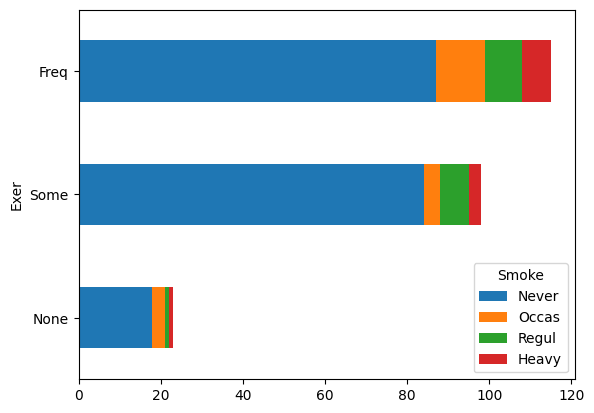

In [37]:
obs = pd.crosstab(df['Exer'], df['Smoke'])
obs.plot(kind='barh', stacked=True)

I expect a somewhat high X2. It seems the people who exercise often also have more smokers.

In [38]:
alpha = 0.05
chi2, p, dof, expected = stats.chi2_contingency(obs)
g = stats.chi2.isf(alpha, df=dof)

print(round(chi2, 3))
print(round(g, 3))
print(round(p, 3))

5.489
12.592
0.483


p > 0.05 so we do not reject H0. This means there is no significant association between exercise frequency and smoking frequency

In [39]:
n = len(df)
k = min(obs.shape)
v = np.sqrt(chi2 / (n * (k - 1)))
print(round(v, 3))

v = stats.contingency.association(obs, method='cramer')
print(round(v, 3))

0.108
0.108


Cramers V shows there is only a weak association

Sex/Smoke: χ² ≈ 3.554, g ≈ 7.815, p ≈ 0.314

H0: There is no association between sex and smoking frequency  
H1: There is an association between sex and smoking frequency

<Axes: ylabel='Sex'>

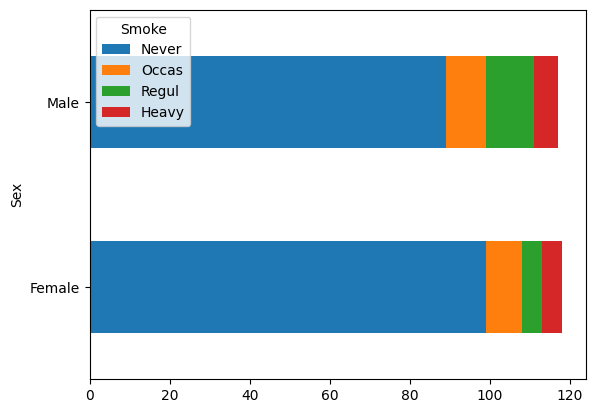

In [40]:
obs = pd.crosstab(df.Sex, df.Smoke)
obs.plot(kind='barh', stacked=True)

It seems men have more smokers. Mostly regular smokers.

In [41]:
chi2, p, dof, expected = stats.chi2_contingency(obs)
g = stats.chi2.isf(alpha, df=dof)

print(round(chi2, 3))
print(round(g, 3))
print(round(p, 3))

v = stats.contingency.association(obs, method='cramer')
print(round(v, 3))

3.554
7.815
0.314
0.123


p > 0.05 so we do not reject the null hypotheses.

W.Hnd/Fold: χ² ≈ 1.581, g ≈ 5.992, p ≈ 0.454

H0: There is no association between w.hnd and fold  
H1: There is an association between w.hnd and fold

<Axes: ylabel='W.Hnd'>

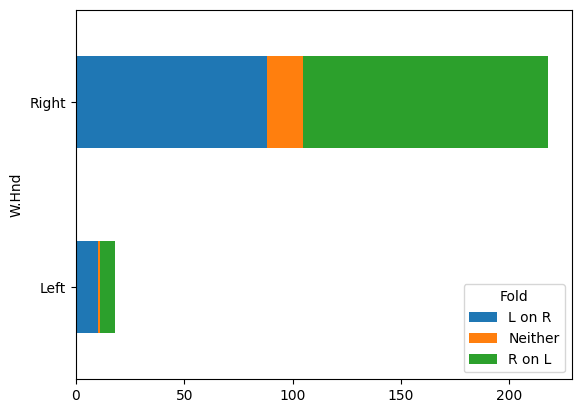

In [ ]:
obs = pd.crosstab(df['W.Hnd'], df['Fold'])
obs.plot(kind='barh', stacked=True)

There doesnt seem to be an association.

In [ ]:
chi2, p, dof, expected = stats.chi2_contingency(obs)
g = stats.chi2.isf(alpha, df=dof)
v = stats.contingency.association(obs, method='cramer')

print(round(chi2, 3))
print(round(g, 3))
print(round(p, 3))
print(round(v, 3))

1.581
5.991
0.454
0.082


p > 0.05 and v is very low. There is a very low association. We do not reject H0.

Sex/W.Hnd: χ² ≈ 0.236, g ≈ 3.842, p ≈ 0.627

H0: There is no association between w.hnd and sex  
H1: There is an association between w.hnd and sex

<Axes: ylabel='Sex'>

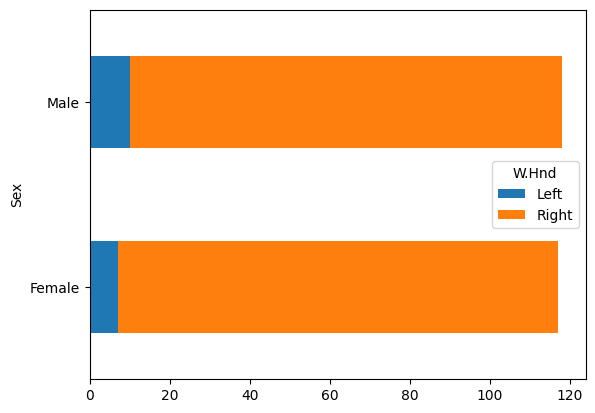

In [45]:
obs = pd.crosstab(df['Sex'], df['W.Hnd'])
obs.plot(kind='barh', stacked=True)

In [ ]:
chi2, p, dof, expected = stats.chi2_contingency(obs)
g = stats.chi2.isf(alpha, df=dof)
v = stats.contingency.association(obs, method='cramer')

print(round(chi2, 3))
print(round(g, 3))
print(round(p, 3))
print(round(v, 3))

0.236
3.841
0.627
0.048


p > alpha, v is very small. There is a tiny association. We do not reject H0